In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# Load dataset
data = pd.read_csv("/content/drive/MyDrive/mager project/creditcard.csv")

# Show first 5 rows
data.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
#Dataset Shape & Info
# Dataset shape
print("Rows, Columns:", data.shape)

# Dataset information
data.info()


Rows, Columns: (284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-n

In [11]:
# Count fraud and normal transactions
data['Class'].value_counts()


,count
Class,
0,284315
1,492


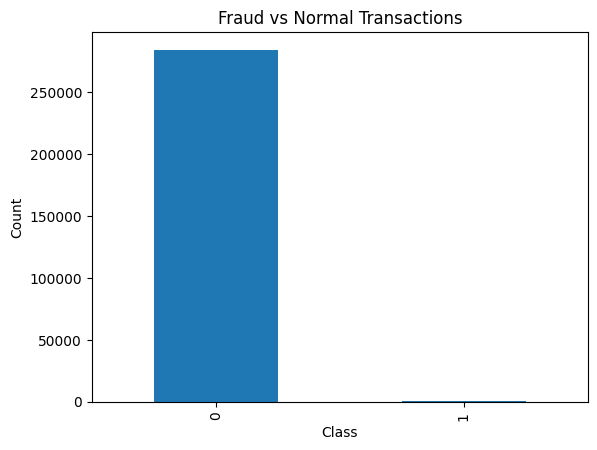

In [12]:
#Simple Visualization (Optional but Good)
data['Class'].value_counts().plot(kind='bar')
plt.title("Fraud vs Normal Transactions")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


In [13]:
#Features–Labels Split & Simple ML Model
#Features (X) & Label (y) Separate
# Features and target
X = data.drop('Class', axis=1)
y = data['Class']

print("Features shape:", X.shape)
print("Labels shape:", y.shape)


Features shape: (284807, 30)
Labels shape: (284807,)


In [14]:
#Train–Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [15]:
#Simple Model Train
#Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [16]:
#Prediction & Accuracy
# Predictions
y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)


Accuracy: 0.9992451107756047


In [17]:
#Detailed Result
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.69      0.76        98

    accuracy                           1.00     56962
   macro avg       0.92      0.85      0.88     56962
weighted avg       1.00      1.00      1.00     56962



In [18]:
# Shuffle dataset
data_shuffled = data.sample(frac=1, random_state=42).reset_index(drop=True)

In [19]:
#Dataset Ko 3 Equal Parts Me Divide karo
# Total samples
total_samples = len(data_shuffled)

# Split size
split_size = total_samples // 3

# Client datasets
client1 = data_shuffled.iloc[:split_size]
client2 = data_shuffled.iloc[split_size:2*split_size]
client3 = data_shuffled.iloc[2*split_size:]

print(len(client1), len(client2), len(client3))


94935 94935 94937


In [20]:
#Client Data Ko X & y Me Convert Karo
def split_xy(client_data):
    X = client_data.drop('Class', axis=1)
    y = client_data['Class']
    return X, y

X1, y1 = split_xy(client1)
X2, y2 = split_xy(client2)
X3, y3 = split_xy(client3)

In [21]:
#Function for Local Training
from sklearn.linear_model import LogisticRegression

def train_local_model(X, y):
    model = LogisticRegression(max_iter=1000)
    model.fit(X, y)
    return model


In [22]:
#Train Model on Each Client
# Client 1
model1 = train_local_model(X1, y1)

# Client 2
model2 = train_local_model(X2, y2)

# Client 3
model3 = train_local_model(X3, y3)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [23]:
#Prediction Example (Optional)
# Check client1 model on its data
y_pred1 = model1.predict(X1)
from sklearn.metrics import accuracy_score
print("Client 1 Accuracy:", accuracy_score(y1, y_pred1))


Client 1 Accuracy: 0.9993469215779217


In [24]:
#Extract Model Coefficients
# Extract weights
w1, b1 = model1.coef_, model1.intercept_
w2, b2 = model2.coef_, model2.intercept_
w3, b3 = model3.coef_, model3.intercept_


In [25]:
#Federated Averaging
# Average weights
w_avg = (w1 + w2 + w3) / 3
b_avg = (b1 + b2 + b3) / 3


In [26]:
# Create a new model
global_model = LogisticRegression(max_iter=1000)

# Set the averaged coefficients
global_model.coef_ = w_avg
global_model.intercept_ = b_avg
global_model.classes_ = np.array([0, 1])  # required

# Test global model on any dataset (e.g., combined test set)
X_test_combined = pd.concat([X1, X2, X3])
y_test_combined = pd.concat([y1, y2, y3])
y_pred_global = global_model.predict(X_test_combined)

print("Global Model Accuracy:", accuracy_score(y_test_combined, y_pred_global))


Global Model Accuracy: 0.9992380805247062


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


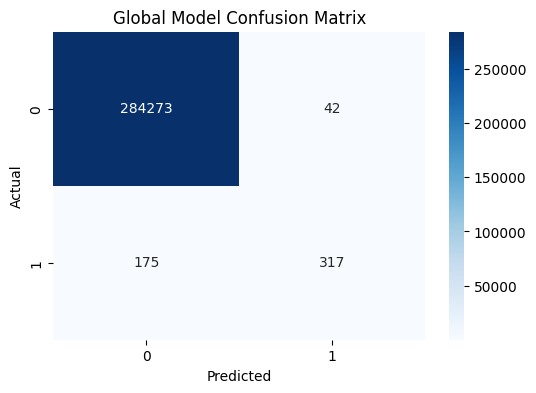

In [27]:
#Confusion Matrix Visualize
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Confusion matrix
cm = confusion_matrix(y_test_combined, y_pred_global)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Global Model Confusion Matrix")
plt.show()


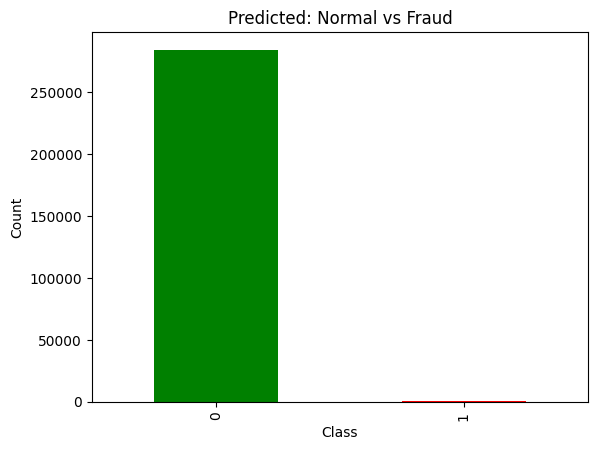

In [28]:
#Fraud vs Normal Prediction Count
import matplotlib.pyplot as plt

# Count of predicted classes
pred_counts = pd.Series(y_pred_global).value_counts()
pred_counts.plot(kind='bar', color=['green', 'red'])
plt.title("Predicted: Normal vs Fraud")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


In [29]:
#Accuracy, Precision, Recall Report
from sklearn.metrics import classification_report

print("Global Model Classification Report:")
print(classification_report(y_test_combined, y_pred_global))


Global Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.88      0.64      0.75       492

    accuracy                           1.00    284807
   macro avg       0.94      0.82      0.87    284807
weighted avg       1.00      1.00      1.00    284807



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


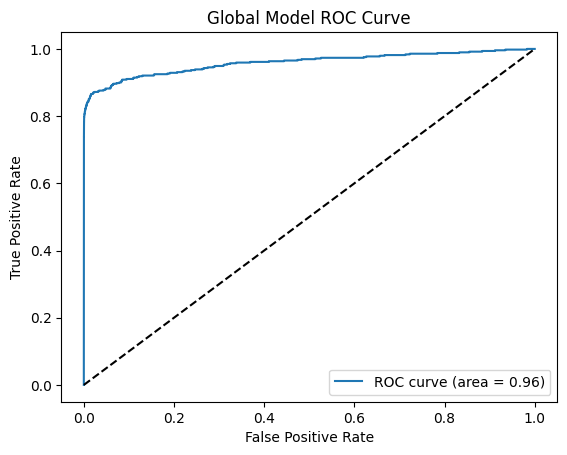

In [30]:
#ROC Curve(optional)
from sklearn.metrics import roc_curve, auc

y_prob = global_model.predict_proba(X_test_combined)[:,1]
fpr, tpr, thresholds = roc_curve(y_test_combined, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Global Model ROC Curve')
plt.legend(loc="lower right")
plt.show()


In [ ]:
!pip install flask-cors
from flask import Flask, request, jsonify
from flask_cors import CORS
import numpy as np

app = Flask(__name__)
CORS(app)

# Use your trained global_model
model = global_model

@app.route("/")
def home():
    return "Federated Fraud Detection API Running"

@app.route("/predict", methods=["POST"])
def predict():
    data = request.json

    features = np.array(data["features"]).reshape(1, -1)

    prediction = model.predict(features)
    prob = model.predict_proba(features)[0][1]

    return jsonify({
        "fraud": int(prediction[0]),
        "probability": float(prob)
    })

app.run(port=5000)

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
ERROR:root:Unexpected exception finding object shape
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/google/colab/_debugpy_repr.py", line 54, in get_shape
    shape = getattr(obj, 'shape', None)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 318, in __get__
    obj = instance._get_current_object()
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 519, in _get_current_object
    raise RuntimeError(unbound_message) from None
RuntimeError: Working outside of request context.

This typically means that you attempted to use functionality that needed
an active HTTP request. Consult the documentation on testing for
information abo

In [35]:
!pip install pyngrok

In [43]:
from pyngrok import ngrok

# You should only pass the authtoken string, not the full command.
# Replace '3C3tQdHeQf5oCoOTC8maJw6Regc_7otE6cJo6iSUigLdutzBc' with your actual authtoken string.
ngrok.set_auth_token("3C3tQdHeQf5oCoOTC8maJw6Regc_7otE6cJo6iSUigLdutzBc")

public_url = ngrok.connect(5000)
print(public_url)

NgrokTunnel: "https://flushedly-unsuggestive-anneliese.ngrok-free.dev" -> "http://localhost:5000"


In [44]:
@app.route("/federated-update", methods=["POST"])
def federated_update():
    global model

    data = request.json
    w_new = np.array(data["weights"])
    b_new = np.array(data["bias"])

    # Simple averaging (simulate server aggregation)
    model.coef_ = (model.coef_ + w_new) / 2
    model.intercept_ = (model.intercept_ + b_new) / 2

    return jsonify({"message": "Global Model Updated"})